# Footstep Log Plotting

`footstep_log.txt`를 읽어 ZMP/COM, foot trajectory, joint trajectory를 시각화합니다. (`plotting.m` 대응)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fname = Path("footstep_log.txt")
n_cols = 47

base = [
    "tick", "walking_tick",
    "ref_zmp_x", "ref_zmp_y", "ref_zmp_z",
    "target_com_stance_x", "target_com_stance_y", "target_com_stance_z",
    "com_stance_x", "com_stance_y", "com_stance_z",
    "com_global_x", "com_global_y", "com_global_z",
    "lfoot_x", "lfoot_y", "lfoot_z",
    "rfoot_x", "rfoot_y", "rfoot_z",
    "target_com_global_x", "target_com_global_y", "target_com_global_z",
]
qdes = [f"q_leg_desired_{i}" for i in range(12)]
qmeas = [f"q_leg_meas_{i}" for i in range(12)]
cols = base + qdes + qmeas
assert len(cols) == n_cols

T = pd.read_csv(
    fname,
    sep="\t",
    skiprows=1,             # 헤더 줄 건너뜀
    header=None,
    names=cols,
    usecols=range(n_cols),  # 끝의 유령 열 제거
    engine="python",
)
# 끊긴 마지막 행 처리 (뒤쪽이 NaN이면 제거)
if T.iloc[-1].isna().any():
    T = T.iloc[:-1]

T.head()

,tick,walking_tick,ref_zmp_x,ref_zmp_y,ref_zmp_z,target_com_stance_x,target_com_stance_y,target_com_stance_z,com_stance_x,com_stance_y,...,q_leg_meas_2,q_leg_meas_3,q_leg_meas_4,q_leg_meas_5,q_leg_meas_6,q_leg_meas_7,q_leg_meas_8,q_leg_meas_9,q_leg_meas_10,q_leg_meas_11
0,0,1,0.002098,-0.112646,0.607138,0.062471,-0.106085,0.610012,0.063019,-0.106971,...,0.000085,1.018082,-0.553240,0.017975,-0.443754,-0.005995,0.002116,1.003065,-0.545029,0.015975
1,1,2,0.005817,-0.100297,0.596296,0.059461,-0.101161,0.602926,0.063059,-0.106862,...,0.004218,1.017053,-0.553468,0.019600,-0.445808,-0.007740,0.006390,1.006777,-0.546558,0.017653
2,2,3,0.010996,-0.083101,0.581199,0.054834,-0.093286,0.591721,0.063340,-0.106284,...,0.013497,1.019257,-0.556228,0.024316,-0.454525,-0.014220,0.016151,1.020312,-0.552944,0.022618
3,3,4,0.016801,-0.063827,0.564278,0.050071,-0.084695,0.579687,0.064061,-0.105221,...,0.019282,1.028862,-0.563550,0.028667,-0.465947,-0.021224,0.024083,1.038337,-0.561805,0.027736
4,4,5,0.022397,-0.045246,0.547965,0.045899,-0.076603,0.568554,0.065485,-0.103095,...,0.022186,1.050392,-0.574677,0.035015,-0.483835,-0.028737,0.032477,1.066777,-0.575636,0.034618


## VRP / Preview / Pelvis trajectory

`ref_zmp`, `target_com_stance`, `com_stance` (x/y/z)

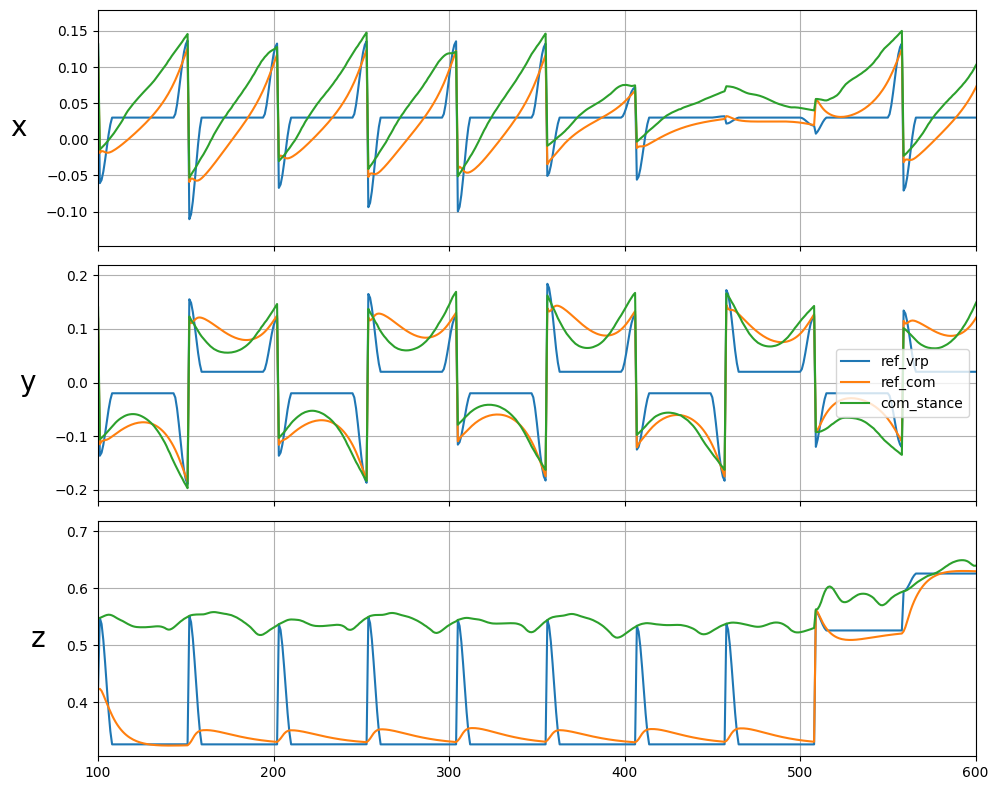

In [2]:
zmp_des = T.filter(regex=r"^ref_zmp").to_numpy()
com_des = T.filter(regex=r"^target_com_stance").to_numpy()
com_cur = T.filter(regex=r"^com_stance").to_numpy()

labels = ["x", "y", "z"]
fig1, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(zmp_des[:, i], label="ref_vrp")
    ax.plot(com_des[:, i], label="ref_com")
    ax.plot(com_cur[:, i], label="com_stance")
    ax.set_ylabel(labels[i], fontsize=20, rotation=0, labelpad=20, va="center")
    ax.set_xlim(100, 600)
    # ax.set_xticks(np.arange(100, 400, 50))
    # ax.set_xticklabels(np.arange(1, 6))
    # ax.tick_params(labelbottom=False, labelleft=False)
    ax.grid(True)
    if i == 1:
        ax.legend(loc="right")
# axes[-1].set_xlabel("sample")
# fig1.suptitle("VRP / Preview / Pelvis (stance frame)")
fig1.tight_layout()
plt.show()


## Foot trajectory (global)

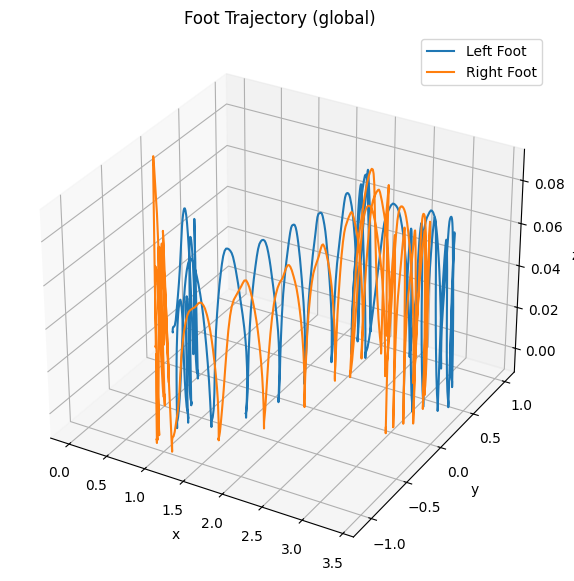

In [3]:
com_global = T.filter(regex=r"^com_global").to_numpy()
lfoot = T.filter(regex=r"^lfoot").to_numpy()
rfoot = T.filter(regex=r"^rfoot").to_numpy()

fig2 = plt.figure(figsize=(8, 7))
ax = fig2.add_subplot(111, projection="3d")
ax.plot(lfoot[:, 0], lfoot[:, 1], lfoot[:, 2], label="Left Foot")
ax.plot(rfoot[:, 0], rfoot[:, 1], rfoot[:, 2], label="Right Foot")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
ax.set_title("Foot Trajectory (global)")

# axis equal (3D)
mins = np.min(np.vstack([lfoot, rfoot]), axis=0)
maxs = np.max(np.vstack([lfoot, rfoot]), axis=0)
centers = 0.5 * (mins + maxs)
radius = 0.5 * np.max(maxs - mins)
# ax.set_xlim(centers[0] - radius, centers[0] + radius)
# ax.set_ylim(centers[1] - radius, centers[1] + radius)
# ax.set_zlim(centers[2] - radius, centers[2] + radius)

plt.show()

## Joint trajectories

`q_leg_desired_*` vs `q_leg_meas_*` (12 joints)

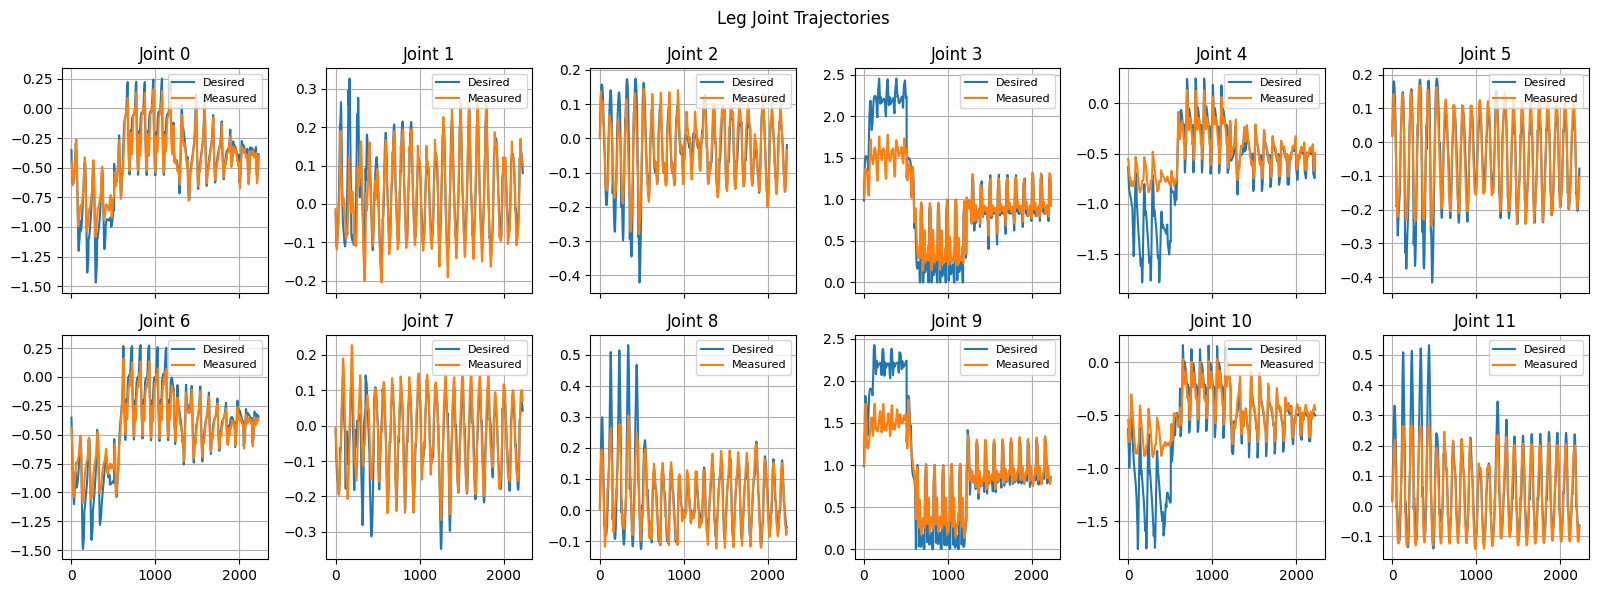

In [4]:
q_des = T.filter(regex=r"^q_leg_desired").to_numpy()
q_meas = T.filter(regex=r"^q_leg_meas").to_numpy()

n_joints = q_des.shape[1]
fig3, axes = plt.subplots(2, 6, figsize=(16, 6), sharex=True)
axes = axes.ravel()
for i in range(n_joints):
    ax = axes[i]
    ax.plot(q_des[:, i], label="Desired")
    ax.plot(q_meas[:, i], label="Measured")
    ax.set_title(f"Joint {i}")
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=8)
fig3.suptitle("Leg Joint Trajectories")
fig3.tight_layout()
plt.show()